In [5]:
import geopandas as gpd
import rasterio
import rasterstats
from rasterio.mask import mask
import random


# vec1 = "data/up_raj1.shp"
# vec2 = "data/up_raj2.shp"
# ras = "data/ndvi_rajshahi.tif"

vec1 = input("Vector Path: ")
ras = input("Raster Path: ")
out = input("output file: ")

gdf = gpd.read_file(vec1)

with rasterio.open(ras) as rcs:
    if gdf.crs != rcs.crs:
        gdf=gdf.to_crs(rcs.crs)
        print("CRS changed")
    
    geo = gdf.geometry
    
    clipped, transform = mask(
        rcs,
        geo,
        crop=True
    )
    metadata = rcs.meta.copy()
    metadata.update({
        "height": clipped.shape[1],
        "width": clipped.shape[2],
        "transform": transform
    })
    
    output = "output/"+ out +".tif"
    
    with rasterio.open(
        output,
        "w",
        **metadata  
    ) as dst:
        dst.write(clipped)
    print("Done")


Done


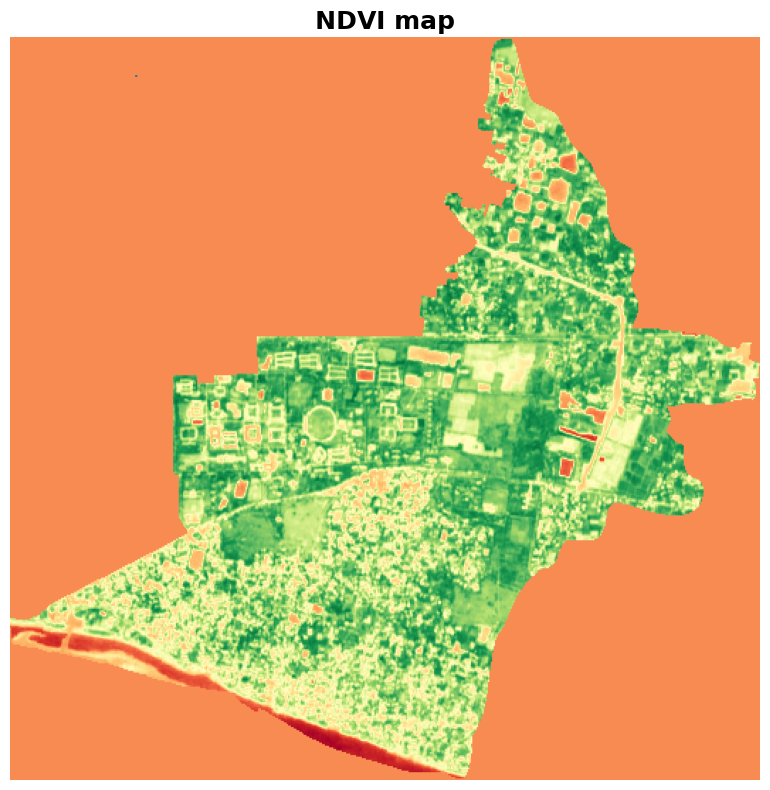

In [7]:
import matplotlib.pyplot as plt

fig, ax=plt.subplots(figsize=(10,8))

ax.imshow(
    clipped[0],
    cmap="RdYlGn"
)

gdf.boundary.plot(
    ax=ax,
    linewidth=1
)

ax.set_title(
    "NDVI map",
    fontsize=18,
    fontweight="bold"
)

ax.set_axis_off()
plt.tight_layout()

plt.savefig(
    "output/"+out+".png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

